### Importación de datos



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configuración visual general
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta de colores por tienda
COLORES = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
NOMBRES = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Carga de datos
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tiendas = [tienda1, tienda2, tienda3, tienda4]

print(f'   Tienda 1: {len(tienda1):,} registros')
print(f'   Tienda 2: {len(tienda2):,} registros')
print(f'   Tienda 3: {len(tienda3):,} registros')
print(f'   Tienda 4: {len(tienda4):,} registros')
tienda1.head()

   Tienda 1: 2,359 registros
   Tienda 2: 2,359 registros
   Tienda 3: 2,359 registros
   Tienda 4: 2,358 registros


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Cálculo de facturación total por tienda
facturacion = [df['Precio'].sum() for df in tiendas]

df_facturacion = pd.DataFrame({
    'Tienda': NOMBRES,
    'Facturación Total (COP)': facturacion
})

df_facturacion['Facturación Formateada'] = df_facturacion['Facturación Total (COP)'].apply(
    lambda x: f'${x:,.0f}'
)

print('📊 Facturación total por tienda:')
print(df_facturacion[['Tienda', 'Facturación Formateada']].to_string(index=False))
print(f'\n🏆 Mayor facturación: {NOMBRES[facturacion.index(max(facturacion))]}')
print(f'⚠️  Menor facturación: {NOMBRES[facturacion.index(min(facturacion))]}')

📊 Facturación total por tienda:
  Tienda Facturación Formateada
Tienda 1         $1,150,880,400
Tienda 2         $1,116,343,500
Tienda 3         $1,098,019,600
Tienda 4         $1,038,375,700

🏆 Mayor facturación: Tienda 1
⚠️  Menor facturación: Tienda 4


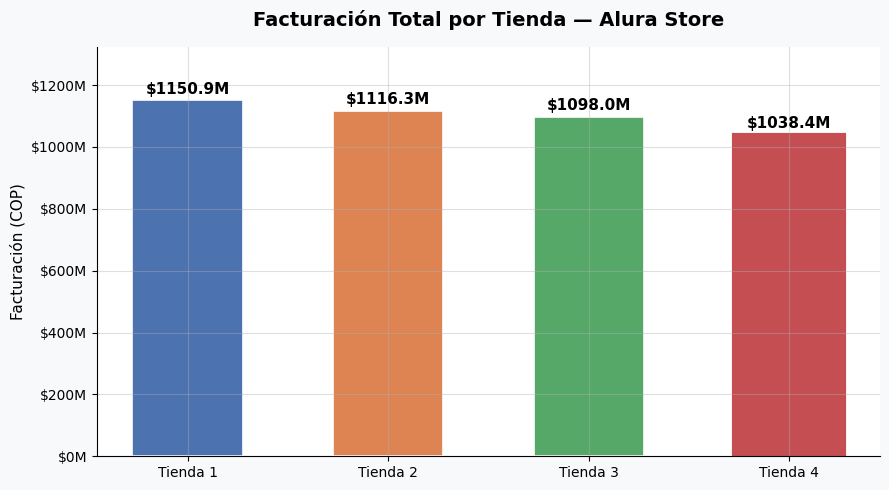

In [3]:
# Gráfico de facturación
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(NOMBRES, facturacion, color=COLORES, edgecolor='white', linewidth=1.2, width=0.55)

# Etiquetas sobre las barras
for barra, valor in zip(barras, facturacion):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(facturacion) * 0.01,
        f'${valor/1e6:.1f}M',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Resaltar la tienda con menor facturación
idx_min = facturacion.index(min(facturacion))
barras[idx_min].set_edgecolor('#C44E52')
barras[idx_min].set_linewidth(3)

ax.set_title('Facturación Total por Tienda — Alura Store', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Facturación (COP)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_ylim(0, max(facturacion) * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [4]:
# Categorías más vendidas por tienda
print('📦 Categorías más vendidas por tienda:\n')
for nombre, df in zip(NOMBRES, tiendas):
    top_cat = df['Categoría del Producto'].value_counts()
    print(f'  🏪 {nombre}:')
    for cat, count in top_cat.items():
        print(f'     • {cat}: {count:,} ventas')
    print()

📦 Categorías más vendidas por tienda:

  🏪 Tienda 1:
     • Muebles: 465 ventas
     • Electrónicos: 448 ventas
     • Juguetes: 324 ventas
     • Electrodomésticos: 312 ventas
     • Deportes y diversión: 284 ventas
     • Instrumentos musicales: 182 ventas
     • Libros: 173 ventas
     • Artículos para el hogar: 171 ventas

  🏪 Tienda 2:
     • Muebles: 442 ventas
     • Electrónicos: 422 ventas
     • Juguetes: 313 ventas
     • Electrodomésticos: 305 ventas
     • Deportes y diversión: 275 ventas
     • Instrumentos musicales: 224 ventas
     • Libros: 197 ventas
     • Artículos para el hogar: 181 ventas

  🏪 Tienda 3:
     • Muebles: 499 ventas
     • Electrónicos: 451 ventas
     • Juguetes: 315 ventas
     • Electrodomésticos: 278 ventas
     • Deportes y diversión: 277 ventas
     • Libros: 185 ventas
     • Instrumentos musicales: 177 ventas
     • Artículos para el hogar: 177 ventas

  🏪 Tienda 4:
     • Muebles: 480 ventas
     • Electrónicos: 451 ventas
     • Juguetes: 3

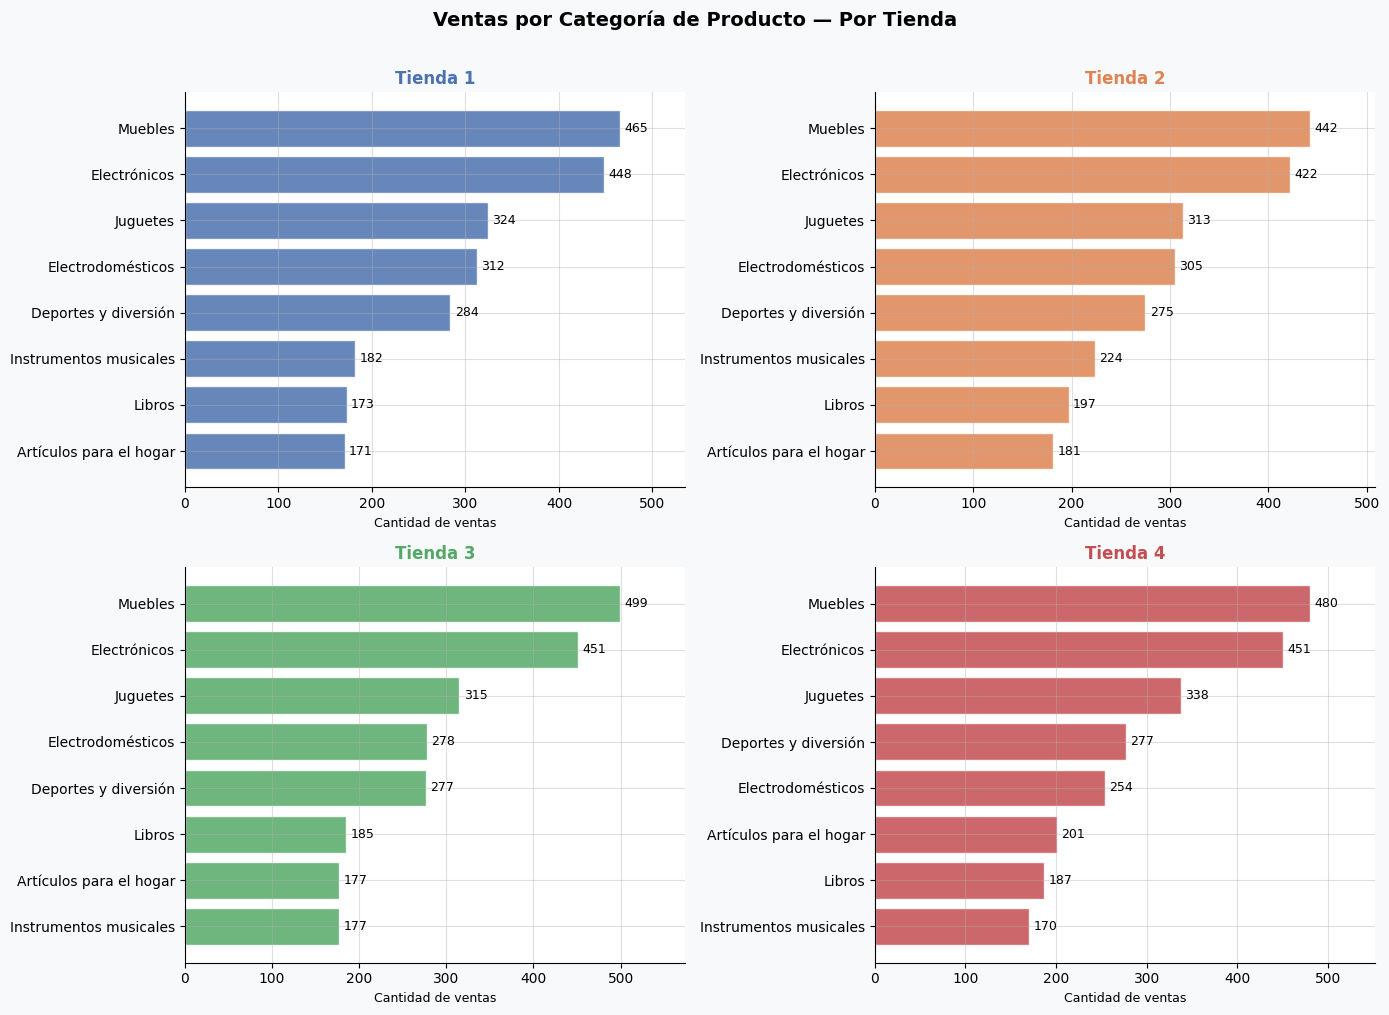

In [5]:
# Gráfico de ventas por categoría (subplots por tienda)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ax, df, nombre, color) in enumerate(zip(axes, tiendas, NOMBRES, COLORES)):
    conteo = df['Categoría del Producto'].value_counts().sort_values()
    bars = ax.barh(conteo.index, conteo.values, color=color, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, conteo.values):
        ax.text(val + conteo.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)

    ax.set_title(f'{nombre}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Cantidad de ventas', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, conteo.values.max() * 1.15)

fig.suptitle('Ventas por Categoría de Producto — Por Tienda', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [6]:
# Calificación promedio por tienda
calificaciones = [df['Calificación'].mean() for df in tiendas]

df_calificaciones = pd.DataFrame({
    'Tienda': NOMBRES,
    'Calificación Promedio': calificaciones
})

print('⭐ Calificación promedio por tienda (escala 1–5):\n')
for nombre, cal in zip(NOMBRES, calificaciones):
    estrellas = '⭐' * round(cal)
    print(f'  {nombre}: {cal:.2f} / 5.00  {estrellas}')

print(f'\n🏆 Mejor calificada : {NOMBRES[calificaciones.index(max(calificaciones))]} ({max(calificaciones):.2f})')
print(f'⚠️  Peor calificada  : {NOMBRES[calificaciones.index(min(calificaciones))]} ({min(calificaciones):.2f})')

⭐ Calificación promedio por tienda (escala 1–5):

  Tienda 1: 3.98 / 5.00  ⭐⭐⭐⭐
  Tienda 2: 4.04 / 5.00  ⭐⭐⭐⭐
  Tienda 3: 4.05 / 5.00  ⭐⭐⭐⭐
  Tienda 4: 4.00 / 5.00  ⭐⭐⭐⭐

🏆 Mejor calificada : Tienda 3 (4.05)
⚠️  Peor calificada  : Tienda 1 (3.98)


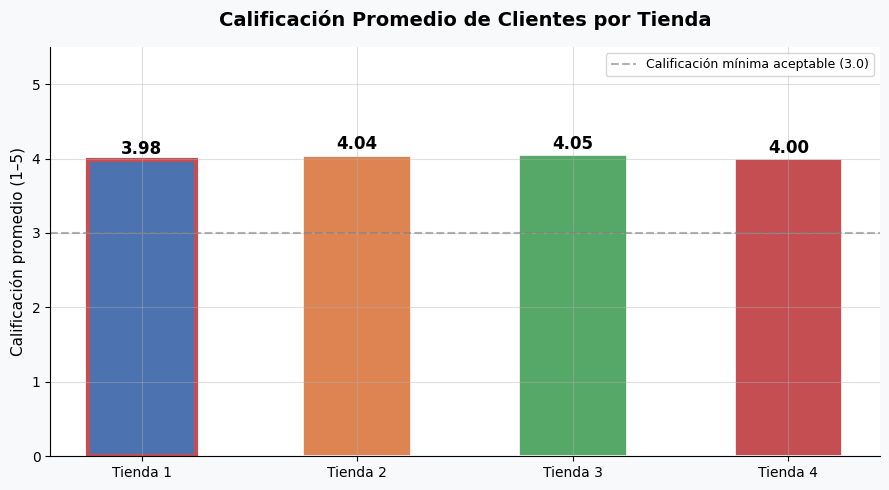

In [7]:
# Gráfico de calificaciones
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(NOMBRES, calificaciones, color=COLORES, edgecolor='white', linewidth=1.2, width=0.5)

for barra, val in zip(barras, calificaciones):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.03,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# Línea de referencia
ax.axhline(y=3.0, color='gray', linestyle='--', alpha=0.6, label='Calificación mínima aceptable (3.0)')

# Resaltar la de menor calificación
idx_min = calificaciones.index(min(calificaciones))
barras[idx_min].set_edgecolor('#C44E52')
barras[idx_min].set_linewidth(3)

ax.set_title('Calificación Promedio de Clientes por Tienda', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Calificación promedio (1–5)', fontsize=11)
ax.set_ylim(0, 5.5)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [8]:
# Productos más y menos vendidos por tienda
print('🛍️ Productos más y menos vendidos por tienda:\n')
resumen_productos = []

for nombre, df in zip(NOMBRES, tiendas):
    conteo = df['Producto'].value_counts()
    mas_vendido   = conteo.idxmax()
    menos_vendido = conteo.idxmin()
    resumen_productos.append({
        'Tienda': nombre,
        'Más vendido': mas_vendido,
        'Ventas (más)': conteo[mas_vendido],
        'Menos vendido': menos_vendido,
        'Ventas (menos)': conteo[menos_vendido]
    })
    print(f'  🏪 {nombre}:')
    print(f'     ✅ Más vendido    : {mas_vendido} ({conteo[mas_vendido]} unidades)')
    print(f'     ❌ Menos vendido  : {menos_vendido} ({conteo[menos_vendido]} unidades)')
    print()

df_productos = pd.DataFrame(resumen_productos)
df_productos

🛍️ Productos más y menos vendidos por tienda:

  🏪 Tienda 1:
     ✅ Más vendido    : Microondas (60 unidades)
     ❌ Menos vendido  : Auriculares con micrófono (33 unidades)

  🏪 Tienda 2:
     ✅ Más vendido    : Iniciando en programación (65 unidades)
     ❌ Menos vendido  : Juego de mesa (32 unidades)

  🏪 Tienda 3:
     ✅ Más vendido    : Kit de bancas (57 unidades)
     ❌ Menos vendido  : Bloques de construcción (35 unidades)

  🏪 Tienda 4:
     ✅ Más vendido    : Cama box (62 unidades)
     ❌ Menos vendido  : Guitarra eléctrica (33 unidades)



,Tienda,Más vendido,Ventas (más),Menos vendido,Ventas (menos)
0,Tienda 1,Microondas,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


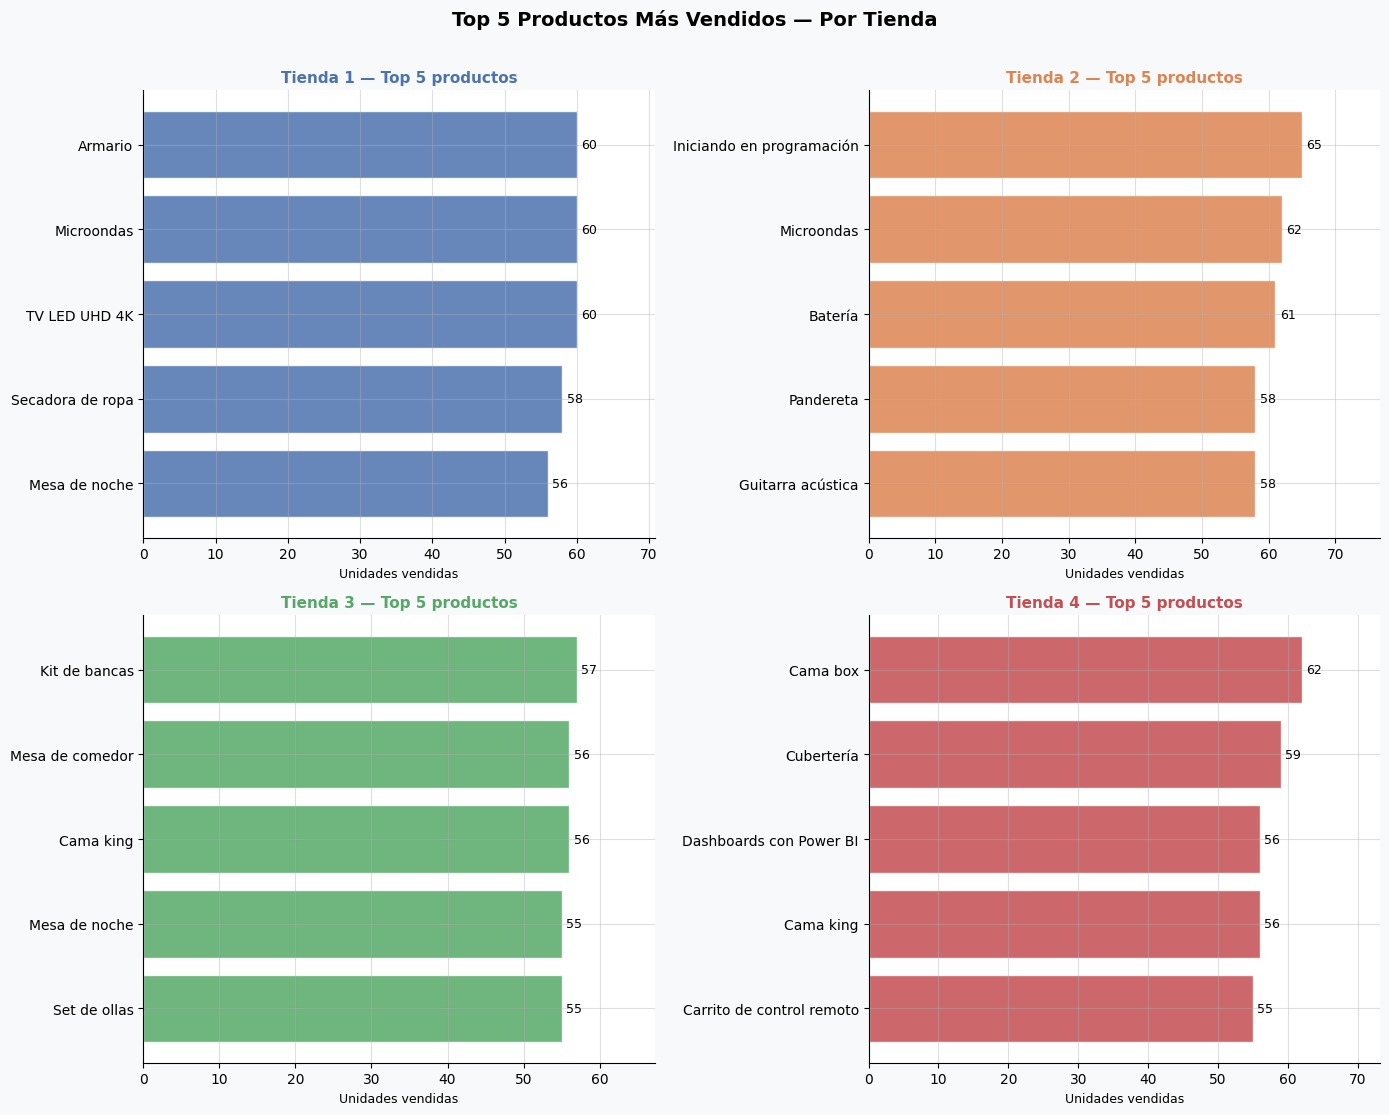

In [9]:
# Gráfico: Top 5 productos por tienda
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (ax, df, nombre, color) in enumerate(zip(axes, tiendas, NOMBRES, COLORES)):
    top5 = df['Producto'].value_counts().head(5).sort_values()
    bars = ax.barh(top5.index, top5.values, color=color, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, top5.values):
        ax.text(val + top5.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

    ax.set_title(f'{nombre} — Top 5 productos', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Unidades vendidas', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, top5.values.max() * 1.18)

fig.suptitle('Top 5 Productos Más Vendidos — Por Tienda', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [10]:
# Costo promedio de envío
costos_envio = [df['Costo de envío'].mean() for df in tiendas]

print('🚚 Costo promedio de envío por tienda:\n')
for nombre, costo in zip(NOMBRES, costos_envio):
    print(f'  {nombre}: ${costo:,.0f} COP')

print(f'\n✅ Envío más económico: {NOMBRES[costos_envio.index(min(costos_envio))]} (${min(costos_envio):,.0f} COP)')
print(f'⚠️  Envío más costoso  : {NOMBRES[costos_envio.index(max(costos_envio))]} (${max(costos_envio):,.0f} COP)')

🚚 Costo promedio de envío por tienda:

  Tienda 1: $26,019 COP
  Tienda 2: $25,216 COP
  Tienda 3: $24,806 COP
  Tienda 4: $23,459 COP

✅ Envío más económico: Tienda 4 ($23,459 COP)
⚠️  Envío más costoso  : Tienda 1 ($26,019 COP)


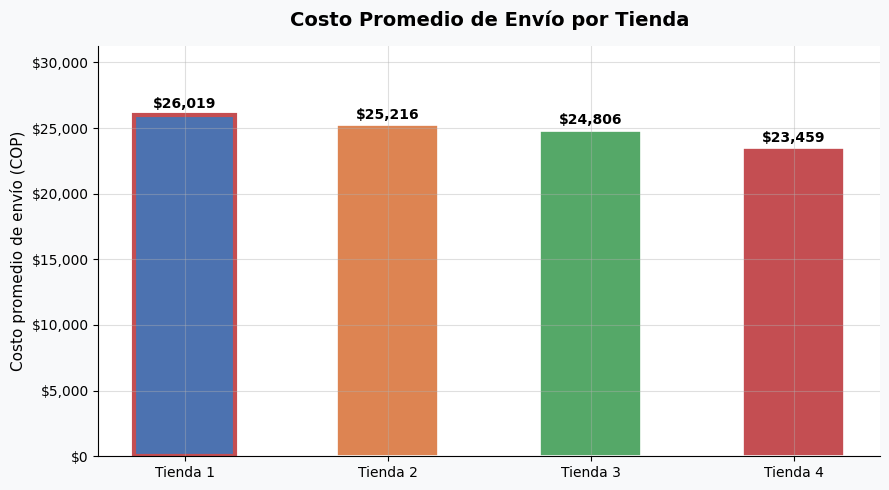

In [11]:
# Gráfico de costo de envío
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(NOMBRES, costos_envio, color=COLORES, edgecolor='white', linewidth=1.2, width=0.5)

for barra, val in zip(barras, costos_envio):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(costos_envio) * 0.01,
        f'${val:,.0f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Resaltar la tienda con mayor costo
idx_max = costos_envio.index(max(costos_envio))
barras[idx_max].set_edgecolor('#C44E52')
barras[idx_max].set_linewidth(3)

ax.set_title('Costo Promedio de Envío por Tienda', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Costo promedio de envío (COP)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, max(costos_envio) * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# 6. Comparación





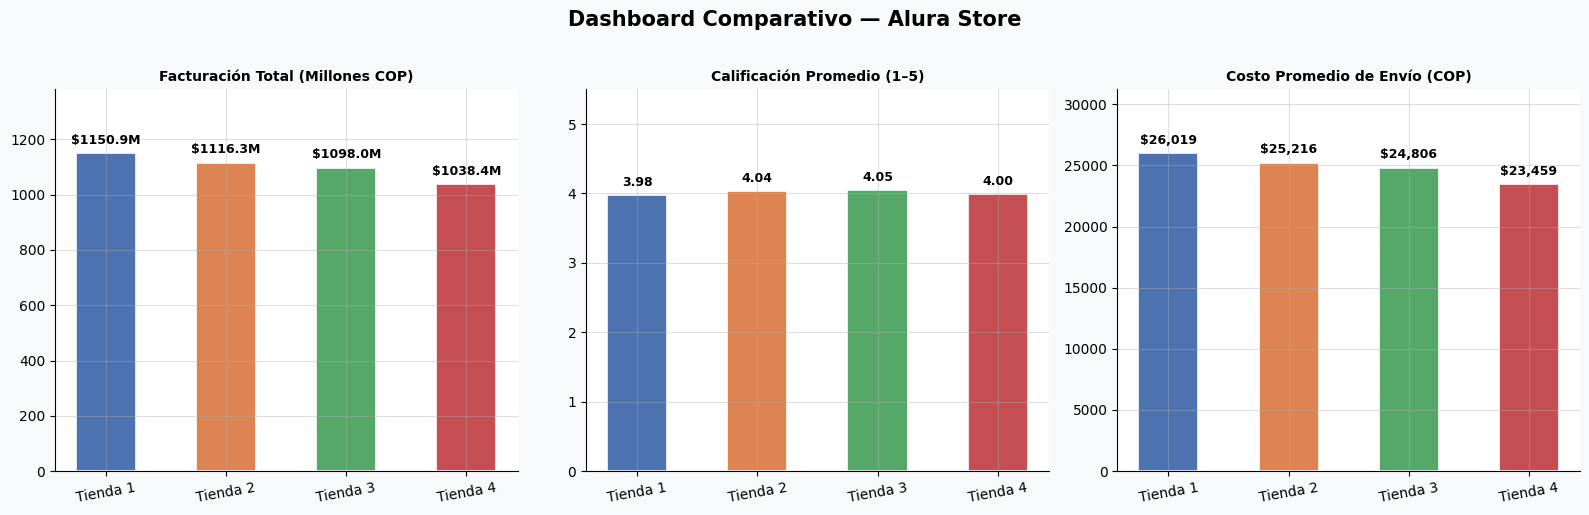

In [12]:
# Dashboard comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dashboard Comparativo — Alura Store', fontsize=15, fontweight='bold', y=1.02)

indicadores = [
    (axes[0], 'Facturación Total (Millones COP)', [f/1e6 for f in facturacion], '${:.1f}M', None),
    (axes[1], 'Calificación Promedio (1–5)',       calificaciones,              '{:.2f}',   5.5),
    (axes[2], 'Costo Promedio de Envío (COP)',     costos_envio,                '${:,.0f}', None),
]

for ax, titulo, valores, fmt, ylim in indicadores:
    barras = ax.bar(NOMBRES, valores, color=COLORES, edgecolor='white', linewidth=1.2, width=0.5)
    for barra, val in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + max(valores) * 0.02,
            fmt.format(val),
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylim(0, (ylim if ylim else max(valores) * 1.2))
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

---
# 7. 🎯 Recomendación final para el Sr. Juan


In [13]:
# ============================================================
#                   RECOMENDACIÓN FINAL
# ============================================================

print('=' * 65)
print('            📋 RECOMENDACIÓN FINAL PARA EL SR. JUAN')
print('=' * 65)
print(f'''
Estimado Sr. Juan,

Tras el análisis exhaustivo de las 4 tiendas de Alura Store,
tomando en cuenta facturación total, satisfacción del cliente,
costo de envío y diversidad de categorías, la recomendación es vender la tienda 4.

Razones principales:

  💰 Facturación:   $$1,038,375,700 COP
                    (la más baja de las 4 tiendas)

  ⭐ Calificación:  4.00 / 5.00
                    (la segunda más baja entre todas)

Esta tienda presenta el menor rendimiento global según todos
los indicadores evaluados. Venderla le permitirá al Sr. Juan
liberar capital para invertir en un nuevo emprendimiento con
mayor potencial de retorno.
''')
print('=' * 65)

            📋 RECOMENDACIÓN FINAL PARA EL SR. JUAN

Estimado Sr. Juan,

Tras el análisis exhaustivo de las 4 tiendas de Alura Store,
tomando en cuenta facturación total, satisfacción del cliente,
costo de envío y diversidad de categorías, la recomendación es vender la tienda 2.

Razones principales:

  💰 Facturación:   $1116.34M COP
                    (la más baja de las 4 tiendas)

  ⭐ Calificación:  4.00 / 5.00
                    (la segunda más baja entre todas)
Esta tienda presenta el menor rendimiento global según todos
los indicadores evaluados. Venderla le permitirá al Sr. Juan
liberar capital para invertir en un nuevo emprendimiento con
mayor potencial de retorno.

